In [13]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
bias_strength = 0.3
data_set_name = "folktables_income"
method_name = "fw-mrs-temperature"
bias_type = "less_positive_class"
iteration = 1

In [15]:
from utils.data_loader import load_dataset
try:
    if DATA_IS_LOADED:
        pass
except:
    _, columns, _ = load_dataset(data_set_name)
    replacer = {}
    for i, feature_name in enumerate(columns):
        replacer[i] = feature_name
DATA_IS_LOADED = True

In [16]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/roc_curves.json"
with open(load_path) as file:
    roc_values = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/none/1.0/uniform/classification_results/roc_curves.json"
with open(representative_uniform_load_path) as file:
    representative_roc_values = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/roc_curves.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_roc_values = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/roc_curves.json"
with open(biased_mrs_load_path) as file:
    biased_mrs_roc_values = json.load(file)

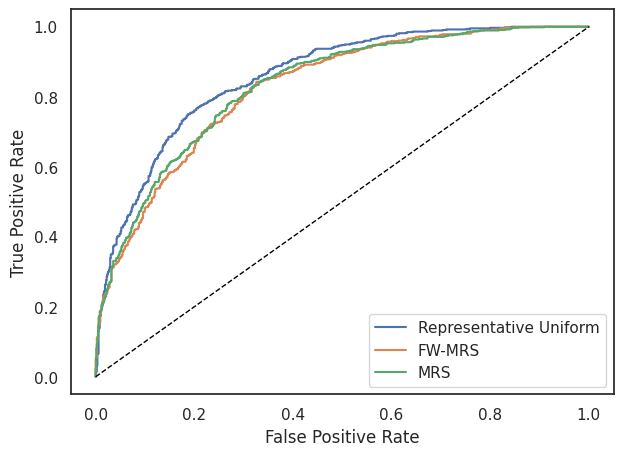

In [17]:
sns.set_theme(rc={'figure.figsize':(7,5)})
one_iteration_roc = roc_values[iteration]
sns.set_style("white")
one_representative_roc = representative_roc_values[iteration]
one_biased_uniform_roc = biased_uniform_roc_values[iteration]
one_biased_mrs_roc = biased_mrs_roc_values[iteration]

plt.plot(one_representative_roc[0], one_representative_roc[1], label="Representative Uniform")
plt.plot(one_iteration_roc[0], one_iteration_roc[1], label="FW-MRS")
#plt.plot(one_biased_uniform_roc[0], one_biased_uniform_roc[1], label="Biased Uniform")
plt.plot(one_biased_mrs_roc[0], one_biased_mrs_roc[1], label="MRS")
plt.plot(
        [0, 1], [0, 1], color="black", linestyle="--", linewidth=1
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

In [18]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/feature_importance.json"
with open(load_path) as file:
    feature_importance = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/none/1.0/uniform/classification_results/feature_importance.json"
with open(representative_uniform_load_path) as file:
    representative_feature_importance = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_feature_importance = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_mrs_feature_importance = json.load(file)

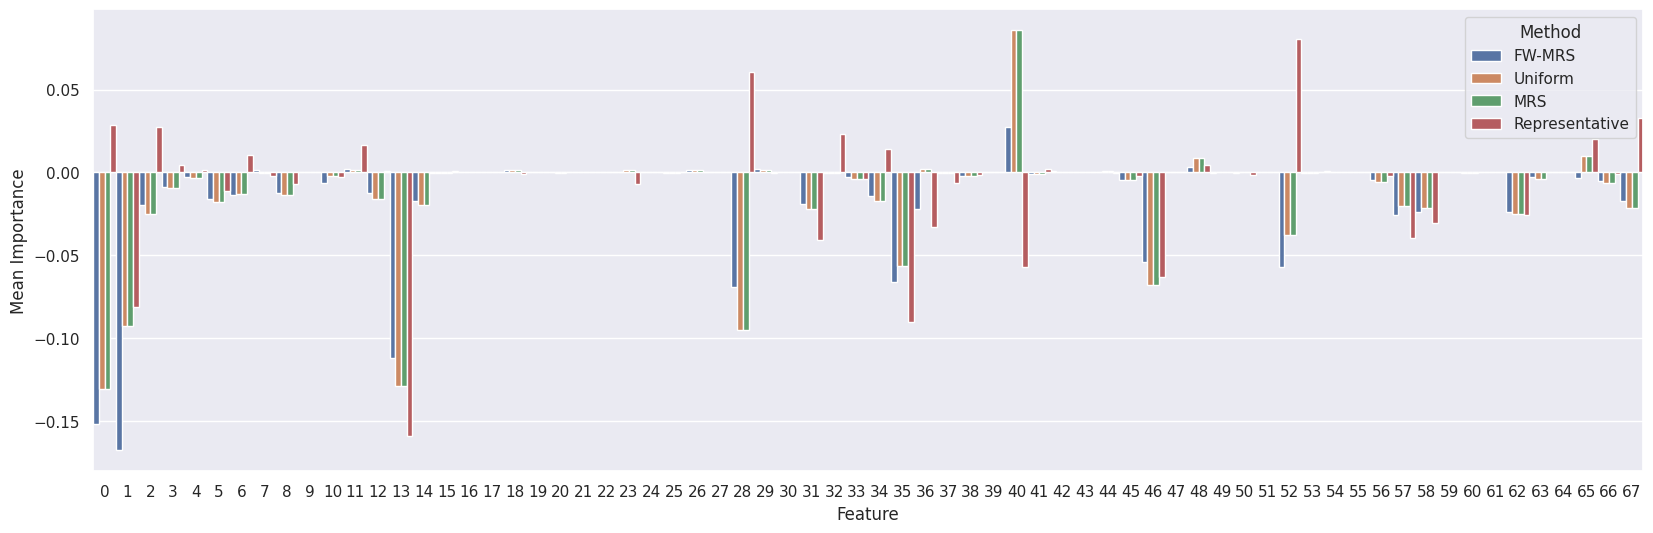

In [19]:
sns.set_theme(rc={'figure.figsize':(20,6)})
mean_iteration_feature_importance = np.mean(feature_importance, axis=0)
mean_iteration_feature_importance /= np.sum(np.abs(mean_iteration_feature_importance))

mean_representative_feature_importance = np.mean(representative_feature_importance, axis=0)
mean_representative_feature_importance /=  np.sum(np.abs(mean_representative_feature_importance))

mean_biased_uniform_feature_importance = np.mean(biased_uniform_feature_importance, axis=0)
mean_biased_uniform_feature_importance /= np.sum(np.abs(mean_biased_uniform_feature_importance))

one_biased_mrs_feature_importance = np.mean(biased_mrs_feature_importance, axis=0)
one_biased_mrs_feature_importance /= np.sum(np.abs(one_biased_mrs_feature_importance))

feature_importances = pd.DataFrame(
    [
        {"Method": "FW-MRS", "Mean Importance": np.array(mean_iteration_feature_importance)},
        {"Method": "Uniform", "Mean Importance": np.array(mean_biased_uniform_feature_importance)},
        {"Method": "MRS", "Mean Importance": np.array(one_biased_mrs_feature_importance)},
        {"Method": "Representative", "Mean Importance": np.array(mean_representative_feature_importance)},
     ]
        )
feature_importances = feature_importances.explode(["Mean Importance"])
feature_importances['Feature'] = feature_importances.groupby('Method').cumcount()
ax = sns.barplot(feature_importances, x="Feature" , y="Mean Importance", hue="Method", width=1)

In [20]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/abs_feature_importance.json"
with open(load_path) as file:
    feature_importance = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/none/1.0/uniform/classification_results/abs_feature_importance.json"
with open(representative_uniform_load_path) as file:
    representative_feature_importance = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/abs_feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_feature_importance = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/abs_feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_mrs_feature_importance = json.load(file)

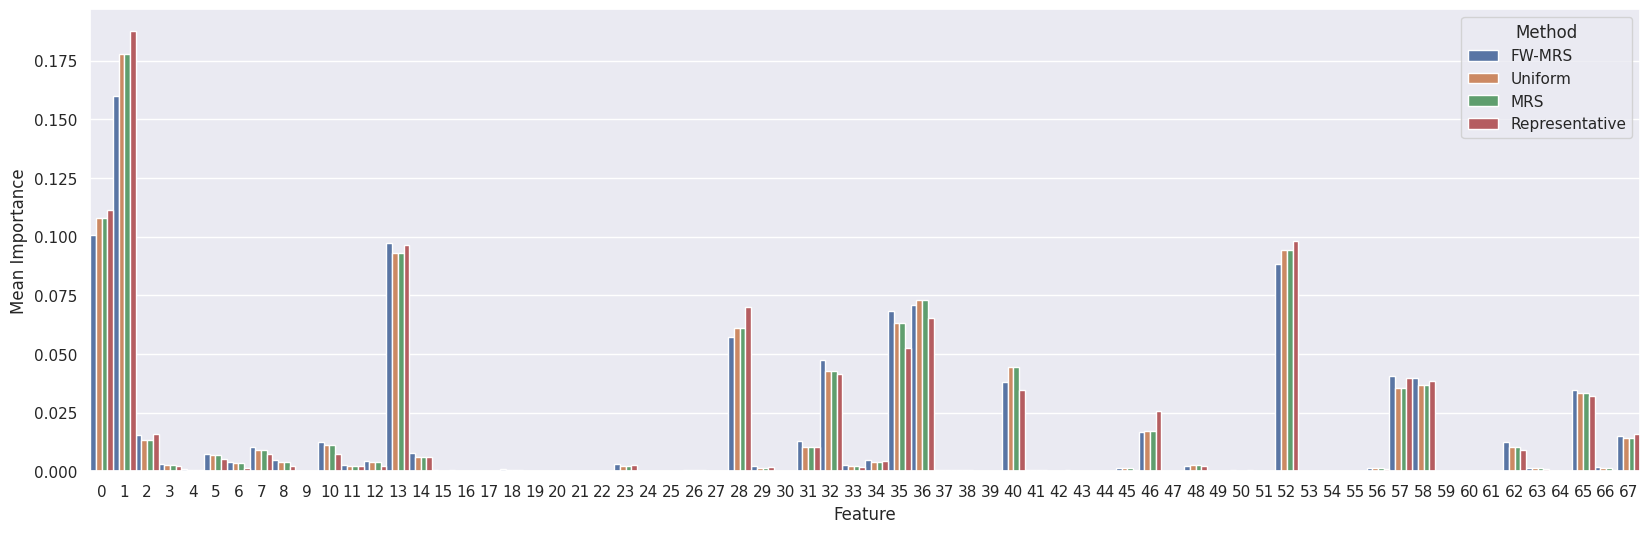

In [21]:
sns.set_theme(rc={'figure.figsize':(20,6)})
mean_iteration_feature_importance = np.mean(feature_importance, axis=0)
mean_iteration_feature_importance /= np.sum(mean_iteration_feature_importance)

mean_representative_feature_importance = np.mean(representative_feature_importance, axis=0)
mean_representative_feature_importance /=  np.sum(mean_representative_feature_importance)

mean_biased_uniform_feature_importance = np.mean(biased_uniform_feature_importance, axis=0)
mean_biased_uniform_feature_importance /= np.sum(mean_biased_uniform_feature_importance)

one_biased_mrs_feature_importance = np.mean(biased_mrs_feature_importance, axis=0)
one_biased_mrs_feature_importance /= np.sum(one_biased_mrs_feature_importance)

feature_importances = pd.DataFrame(
    [
        {"Method": "FW-MRS", "Mean Importance": np.array(mean_iteration_feature_importance)},
        {"Method": "Uniform", "Mean Importance": np.array(mean_biased_uniform_feature_importance)},
        {"Method": "MRS", "Mean Importance": np.array(one_biased_mrs_feature_importance)},
        {"Method": "Representative", "Mean Importance": np.array(mean_representative_feature_importance)},
     ]
        )
feature_importances = feature_importances.explode(["Mean Importance"])
feature_importances['Feature'] = feature_importances.groupby('Method').cumcount()
ax = sns.barplot(feature_importances, x="Feature" , y="Mean Importance", hue="Method", width=1)

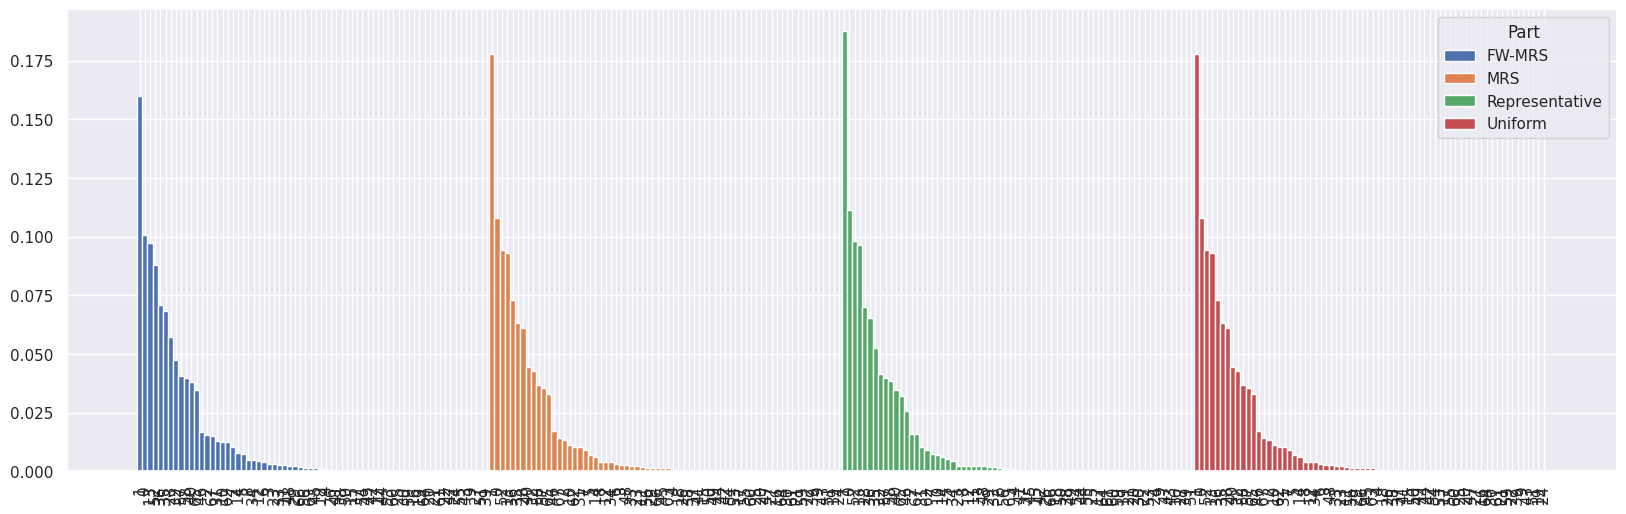

In [22]:
fig, ax = plt.subplots()
offset = 5 / len(columns)
xticks, xlabels = [], []
handles, labels = [], []
feature_importances['Mean Importance'] = feature_importances['Mean Importance'].astype("float32")
for i, (idx, group) in enumerate(feature_importances.groupby('Method')):
    # print(group)
    plot_data = group.nlargest(len(columns), 'Mean Importance')
    # print(plot_data)
    x = [ (5 * i) + x * offset for x in range(len(columns))]
    # x = [i, i + offset, i + (2 * offset)]
    barcontainer = ax.bar(x=x, height=plot_data['Mean Importance'], width= 5 / len(columns))
    
    xticks += x
    xlabels += plot_data['Feature'].tolist()
    handles.append(barcontainer[0])
    labels.append(idx)

plt.rcParams['xtick.labelsize'] = 10
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.legend(handles=handles, labels=labels, title='Part')
plt.xticks(rotation = 90)
plt.show()

In [23]:
feature_importances["Feature"] = feature_importances["Feature"].replace(replacer)
tmp = feature_importances.sort_values(["Method", "Mean Importance"], ascending=False)
print(tmp)

     Method  Mean Importance  \
1   Uniform         0.177904   
1   Uniform         0.108011   
1   Uniform         0.094165   
1   Uniform         0.092840   
1   Uniform         0.073076   
..      ...              ...   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   

                                              Feature  
1                                                WKHP  
1                                                AGEP  
1                               RELP_Reference person  
1                              SCHL_Bachelor's degree  
1             MAR_Never married or under 15 years old  
..                                                ...  
0                                  RELP_Parent-in-law  
0                        RELP_Stepson or stepdaughter  
0                           RAC1P_Alaska Native alone  
0   RAC1P_American Indian and Alaska Native tribes...  

In [24]:
tmp.groupby("Method").head(10)

,Method,Mean Importance,Feature
1,Uniform,0.177904,WKHP
1,Uniform,0.108011,AGEP
1,Uniform,0.094165,RELP_Reference person
1,Uniform,0.092840,SCHL_Bachelor's degree
1,Uniform,0.073076,MAR_Never married or under 15 years old
1,Uniform,0.063155,MAR_Married
1,Uniform,0.060959,SCHL_Master's degree
1,Uniform,0.044602,RELP_Biological son or daughter
1,Uniform,0.042806,SCHL_Regular high school diploma
1,Uniform,0.036808,SEX_Male
